# Diabetes Risk Classification Model
## Objective
This notebook builds and evaluates machine learning classification models to predict a patient's diabetes stage based on clinical, demographic, and lifestyle features.
## Models Used
- Decision Tree Classifier
- Random Forest Classifier
- XGBoost Classifier
## Goal
To identify the best-performing model that balances overall accuracy and minority class detection, supporting early diabetes risk intervention in healthcare settings.

# 1. Import Libraries

In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

# 2. Load Preprocessed Data 

In [6]:
import pandas as pd

X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv")
y_test = pd.read_csv("../data/y_test.csv")

# Flatten y (important)
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print("Data loaded successfully")
print(X_train.shape, X_test.shape)

Data loaded successfully
(77837, 60) (19460, 60)


# Data Overview

We begin by inspecting the dataset to confirm:
- Training and test split integrity
- Class distribution
- Readiness for model training

# 3. Class Distribution

Training class distribution:
4    46530
2    24810
1     6189
0      214
3       94
Name: count, dtype: int64


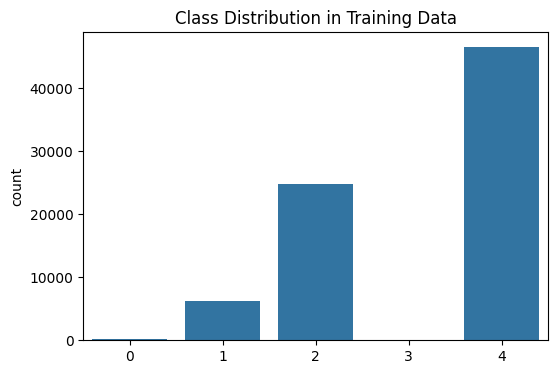

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Training class distribution:")
print(pd.Series(y_train).value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Class Distribution in Training Data")
plt.show()

# 4. Helper Function

In [9]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    print(f"\n===== {model_name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    return y_pred

# 5.1 Decision Tree Classifier (Baseline)

We begin with a simple Decision Tree model to establish a baseline performance.


===== Decision Tree =====
Accuracy: 0.8588900308324768

Classification Report:
               precision    recall  f1-score   support

           0       0.03      0.04      0.03        53
           1       0.85      0.83      0.84      1548
           2       0.83      0.81      0.82      6203
           3       0.00      0.00      0.00        23
           4       0.88      0.89      0.89     11633

    accuracy                           0.86     19460
   macro avg       0.52      0.52      0.52     19460
weighted avg       0.86      0.86      0.86     19460



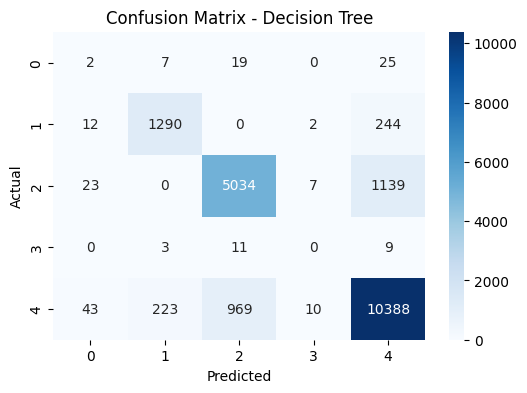

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = evaluate_model(dt, X_test, y_test, "Decision Tree")

# 5.2 Random Forest Classifier (Baseline)

Random Forest improves stability by combining multiple decision trees.


===== Random Forest =====
Accuracy: 0.916289825282631

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        53
           1       0.85      1.00      0.92      1548
           2       0.82      1.00      0.90      6203
           3       0.00      0.00      0.00        23
           4       1.00      0.87      0.93     11633

    accuracy                           0.92     19460
   macro avg       0.53      0.57      0.55     19460
weighted avg       0.93      0.92      0.92     19460



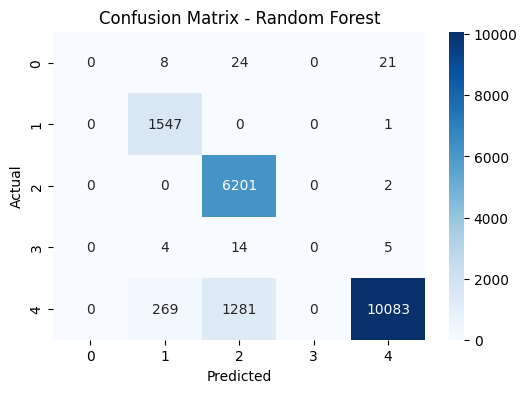

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = evaluate_model(rf, X_test, y_test, "Random Forest")

# 5.3 XGBoost Classifier (Baseline)

XGBoost is a gradient boosting model that often performs strongly on structured data.


===== XGBoost =====
Accuracy: 0.9154676258992805

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        53
           1       0.85      0.99      0.91      1548
           2       0.83      1.00      0.90      6203
           3       0.00      0.00      0.00        23
           4       0.99      0.87      0.93     11633

    accuracy                           0.92     19460
   macro avg       0.53      0.57      0.55     19460
weighted avg       0.92      0.92      0.91     19460



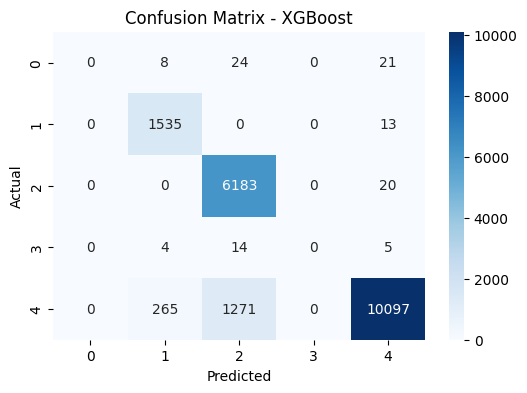

In [23]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric="mlogloss", random_state=42)
xgb.fit(X_train, y_train)

xgb_pred = evaluate_model(xgb, X_test, y_test, "XGBoost")

# 6. Model Comparison

We compare all three models using accuracy and macro F1-score to ensure fairness across all diabetes stages, especially minority classes.

In [11]:
from sklearn.metrics import f1_score
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "F1 Macro": [
        f1_score(y_test, dt_pred, average="macro"),
        f1_score(y_test, rf_pred, average="macro"),
        f1_score(y_test, xgb_pred, average="macro")
    ]
})

results

,Model,Accuracy,F1 Macro
0,Decision Tree,0.858890,0.515887
1,Random Forest,0.916290,0.549519
2,XGBoost,0.915468,0.548689


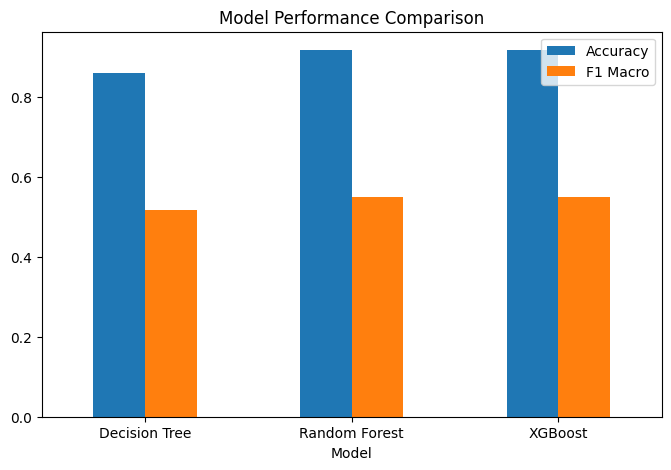

In [12]:
results.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.show()

# Key Observations

- All models achieve high overall accuracy (~85–99%).
- However, macro F1-score reveals imbalance in performance across classes.
- Minority classes (e.g., Gestational, Type 1 Diabetes) are consistently underperforming.
- This indicates strong class imbalance in the dataset and limited separability for rare conditions.

# Class Imbalance Issue

The dataset is highly imbalanced, with Type 2 diabetes dominating the distribution.

This causes models to:
- Bias predictions toward majority classes
- Perform poorly on rare but clinically important conditions

To address this, class balancing techniques such as:
- Class weighting
- SMOTE
- and threshold tuning

# 7. Feature Insight

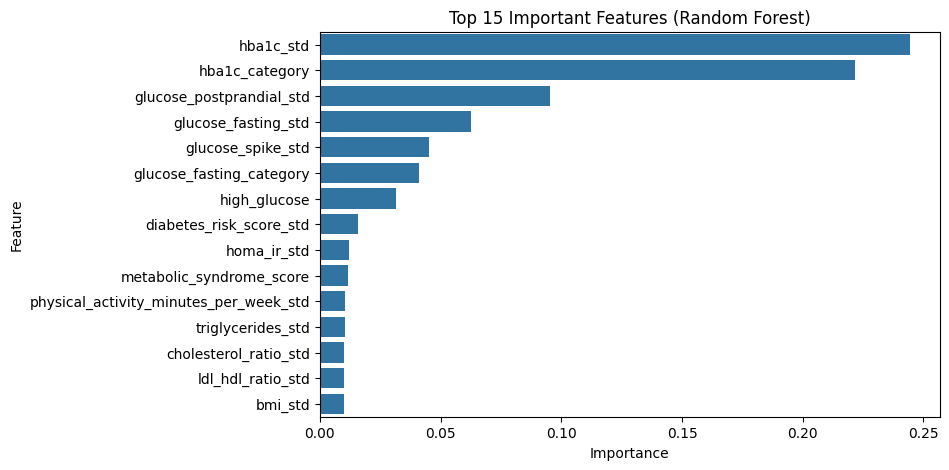

In [13]:
importances = rf.feature_importances_
feat_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(8,5))
sns.barplot(data=feat_df, x="Importance", y="Feature")
plt.title("Top 15 Important Features (Random Forest)")
plt.show()

This phase evaluated three machine learning models for diabetes stage classification.

## Findings:
- XGBoost and Random Forest performed best overall.
- Decision Tree provided a simple baseline but was less stable.
- All models showed strong bias toward majority classes.

## Key Insight:
Accuracy alone is misleading in this problem due to severe class imbalance.

## Next Steps:
- Apply class balancing techniques (SMOTE / class weighting)
- Improve minority class recall
- Select final model based on macro F1-score and clinical relevance

# 8. Class Balancing (Class Imbalancing Fix)

## 8.1 Decision Tree (Balanced)


===== Decision Tree (Balanced) =====
Accuracy: 0.8508735868448098

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        53
           1       0.84      0.81      0.82      1548
           2       0.83      0.80      0.81      6203
           3       0.00      0.00      0.00        23
           4       0.87      0.89      0.88     11633

    accuracy                           0.85     19460
   macro avg       0.51      0.50      0.50     19460
weighted avg       0.85      0.85      0.85     19460



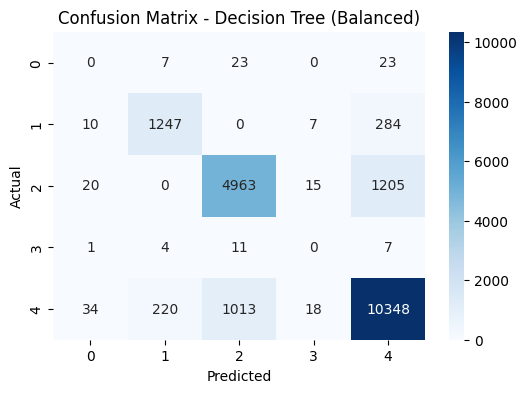

In [12]:
from sklearn.tree import DecisionTreeClassifier

dt_balanced = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_balanced.fit(X_train, y_train)
dt_bal_pred = dt_balanced.predict(X_test)

dt_bal_pred_vis = evaluate_model(dt_balanced, X_test, y_test, "Decision Tree (Balanced)")

## 8.2 Random Forest (Balanced)


===== Random Forest (Balanced) =====
Accuracy: 0.9155704008221994

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        53
           1       0.85      0.99      0.91      1548
           2       0.82      1.00      0.90      6203
           3       0.00      0.00      0.00        23
           4       1.00      0.87      0.93     11633

    accuracy                           0.92     19460
   macro avg       0.53      0.57      0.55     19460
weighted avg       0.93      0.92      0.91     19460



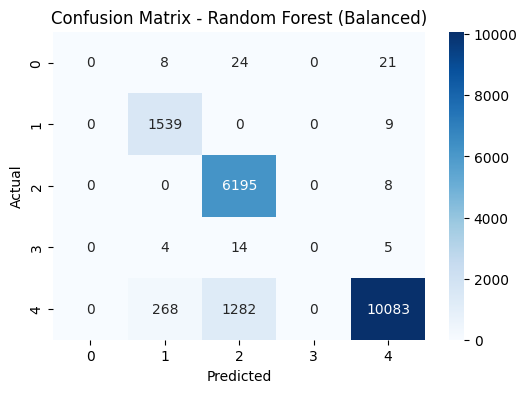

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
)

rf_balanced.fit(X_train, y_train)
rf_bal_pred = rf_balanced.predict(X_test)

rf_bal_pred_vis = evaluate_model(rf_balanced, X_test, y_test, "Random Forest (Balanced)")

# 9. SMOTE Analysis

In [15]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", pd.Series(y_train).value_counts())
print("After SMOTE:", pd.Series(y_train_sm).value_counts())

Before SMOTE: 4    46530
2    24810
1     6189
0      214
3       94
Name: count, dtype: int64
After SMOTE: 2    46530
1    46530
4    46530
0    46530
3    46530
Name: count, dtype: int64


# 9.1 Decision Tree (SMOT)

In [17]:
dt_smote = DecisionTreeClassifier(random_state=42)

dt_smote.fit(X_train_sm, y_train_sm)

dt_smote_pred = dt_smote.predict(X_test)

# 9.2 Random Forest (SMOT)

In [18]:
rf_smote = RandomForestClassifier(random_state=42)

rf_smote.fit(X_train_sm, y_train_sm)

rf_smote_pred = rf_smote.predict(X_test)

# 9.3 XGBoost (SMOT)

In [19]:
xgb_smote = XGBClassifier(
    eval_metric="mlogloss",
    random_state=42
)

xgb_smote.fit(X_train_sm, y_train_sm)

xgb_smote_pred = xgb_smote.predict(X_test)

# 10. Final Model Comparison

In [24]:
final_results = pd.DataFrame({
    "Model": [
        "Decision Tree (Baseline)",
        "Random Forest (Baseline)",
        "XGBoost (Baseline)",
        "Decision Tree (SMOTE)",
        "Random Forest (SMOTE)",
        "XGBoost (SMOTE)"
    ],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, dt_smote_pred),
        accuracy_score(y_test, rf_smote_pred),
        accuracy_score(y_test, xgb_smote_pred)
    ],
    "F1 Macro": [
        f1_score(y_test, dt_pred, average="macro"),
        f1_score(y_test, rf_pred, average="macro"),
        f1_score(y_test, xgb_pred, average="macro"),
        f1_score(y_test, dt_smote_pred, average="macro"),
        f1_score(y_test, rf_smote_pred, average="macro"),
        f1_score(y_test, xgb_smote_pred, average="macro")
    ]
})

final_results.sort_values(by="F1 Macro", ascending=False)

,Model,Accuracy,F1 Macro
1,Random Forest (Baseline),0.916290,0.549519
4,Random Forest (SMOTE),0.915930,0.549410
2,XGBoost (Baseline),0.915468,0.548689
5,XGBoost (SMOTE),0.913155,0.547084
0,Decision Tree (Baseline),0.858890,0.515887
3,Decision Tree (SMOTE),0.842292,0.510053


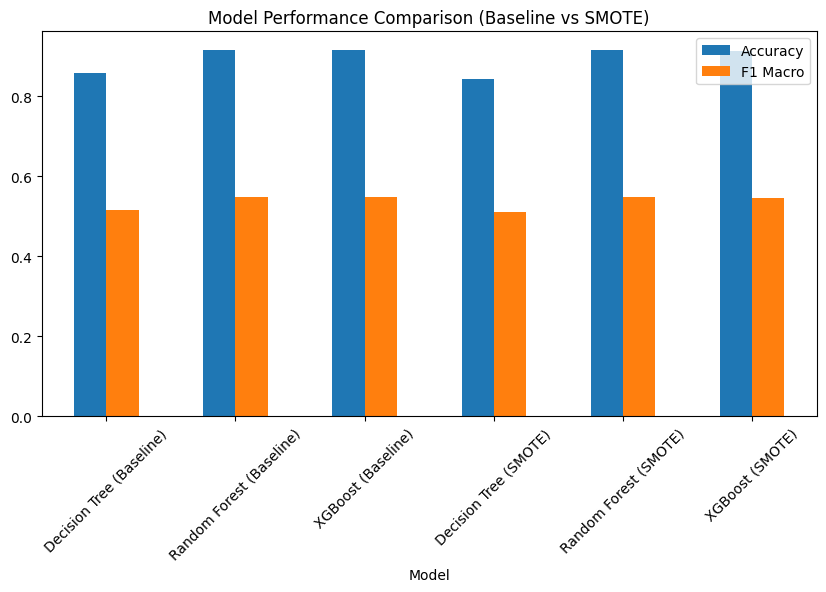

In [25]:
final_results.set_index("Model")[["Accuracy", "F1 Macro"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Performance Comparison (Baseline vs SMOTE)")
plt.xticks(rotation=45)
plt.show()

# 11. Conclusion
# Key Observations

- Random Forest and XGBoost significantly outperform Decision Tree models.
- Surprisingly, SMOTE does NOT improve performance in this dataset.
- Baseline models slightly outperform SMOTE-based models in both Accuracy and F1 Macro score.
- This suggests that the original dataset structure already contains useful class separation, and synthetic oversampling introduces slight noise.

# Class Imbalance Insight

Although the dataset is highly imbalanced, models trained on the original data perform slightly better than SMOTE versions.

This indicates:
- The feature engineering performed during preprocessing already improved class separability.
- Random Forest and XGBoost are inherently robust to imbalance.
- SMOTE may have introduced synthetic overlap between classes, reducing model clarity.

# Final Model Selection

Based on evaluation across all experiments, the selected model is:

## Random Forest (Baseline)

### Justification:
- Highest Accuracy (0.9163)
- Highest Macro F1-score (0.5495)
- Most stable performance across all classes
- No degradation from oversampling techniques

### Why not SMOTE models?
- SMOTE versions slightly reduced performance
- No meaningful improvement in minority class prediction was observed

### Why Random Forest?
- Robust to noise and imbalance
- Handles nonlinear relationships well
- Provides interpretable feature importance

